# Stage 2: Linear/RBF SBEED With SGD Rho

This notebook applies the terminal-aware SGD-rho solver to fixed linear and RBF-style features. It connects the practical replay changes from Stage 2 with the representation limitations seen in the linear Stage 1 notebook.

What to look for:
- terminal handling in larger grids with walls, goal, and pit,
- sensitivity of rho learning under approximate features,
- differences between tabular and RBF-style behavior.


In [1]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import sys
import torch
from pathlib import Path
import matplotlib.pyplot as plt

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def find_root(current_path):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / "src" / "rl_methods").exists() and (parent / "data").exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rl_methods.sbeed import (
    SBEEDSolverSGDRho,
    DiscreteMDPSpec,
    RBFStateFeatures,
    RBFStateActionFeatures,
    TabularStateFeatures,
    SBEEDEvaluator,
)

# 3grid

In [2]:
def plot_grid_with_rbf(
    grid_size,
    centers,
    variance,
    values=None,
    policy=None,
    goal_grid=None,
    pit_grid=None,
    wall_states=None,
    terminal_states=None,
    title="Grid World with RBF Centers",
):
    """
    Plot a square grid with optional values, policy arrows, RBF centers, and RBF radius.
    Preserves original styling while adding robust support for walls and pits.
    """
    centers = torch.as_tensor(centers, dtype=torch.float64)

    if centers.ndim != 2 or centers.shape[1] != 2:
        raise ValueError("centers must have shape [K, 2] as normalized [row, col] coordinates")

    variance = torch.as_tensor(variance, dtype=torch.float64).reshape(-1)
    if variance.numel() == 1:
        variance = variance.repeat(centers.shape[0])
    if variance.numel() != centers.shape[0]:
        raise ValueError("variance must be scalar or have one value per center")

    radius = torch.sqrt(variance)

    N = grid_size * grid_size
    
    # Consistency: Ensure these are all sets for the 'in' checks
    def to_set(x):
        if x is None: return set()
        if isinstance(x, (int, float, np.integer)): return {int(x)}
        return set(int(s) for s in x)

    goals = to_set(goal_grid)
    pits = to_set(pit_grid)
    walls = to_set(wall_states)
    terminals = to_set(terminal_states) | goals | pits

    def state_to_pos(s):
        return divmod(int(s), grid_size)

    fig, ax = plt.subplots(figsize=(8, 8))

    grid = np.zeros((grid_size, grid_size))

    if values is not None:
        if hasattr(values, "detach"):
            values = values.detach().cpu().numpy()
        values = np.asarray(values)
        grid = values.reshape(grid_size, grid_size)

    # REVERTED: Original background logic
    ax.imshow(
        grid,
        cmap="viridis",
        origin="upper",
        alpha=0.3 if values is not None else 0.1,
    )

    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=2)

    if policy is not None and hasattr(policy, "detach"):
        policy = policy.detach().cpu().numpy()

    for s in range(N):
        r, c = state_to_pos(s)

        # REVERTED: Original rectangle and text logic
        if s in goals:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="green", alpha=0.5))
            ax.text(c, r, "GOAL", ha="center", va="center", fontweight="bold")

        elif s in pits:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="red", alpha=0.5))
            ax.text(c, r, "PIT", ha="center", va="center", fontweight="bold", color="white")

        elif s in walls:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="gray"))
            ax.text(c, r, "WALL", ha="center", va="center", fontweight="bold", color="white")

        else:
            ax.text(c - 0.4, r - 0.4, str(s), fontsize=8, color="gray")
            if values is not None:
                ax.text(c, r, f"{values[s]:.2f}", ha="center", va="center", fontsize=10)

        # Draw Policy Arrows (excluding terminals and walls)
        if policy is not None and s not in terminals and s not in walls:
            if len(policy.shape) == 2:
                best_action = np.argmax(policy[s], axis=-1)
            else:
                best_action = policy[s]

            dx, dy = 0.0, 0.0
            if best_action == 0:      dy = -0.3
            elif best_action == 1:    dy = 0.3
            elif best_action == 2:    dx = -0.3
            elif best_action == 3:    dx = 0.3

            ax.arrow(c, r, dx, dy, head_width=0.1, head_length=0.1, fc="black", ec="black")

    # REVERTED: Original RBF Center styling
    for i, center in enumerate(centers):
        row_norm, col_norm = center.tolist()

        r = row_norm * (grid_size - 1)
        c = col_norm * (grid_size - 1)
        radius_cells = radius[i].item() * (grid_size - 1)

        circle = plt.Circle(
            (c, r),
            radius_cells,
            color="tab:red",
            fill=False,
            linewidth=2,
            alpha=0.8,
        )
        ax.add_patch(circle)

        ax.scatter(c, r, color="tab:red", marker="x", s=120, linewidths=3)
        ax.text(
            c,
            r + 0.18,
            f"c{i}",
            ha="center",
            va="bottom",
            color="tab:red",
            fontweight="bold",
        )

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(grid_size - 0.5, -0.5)
    plt.show()

In [3]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
goal_grid = 8

def to_rc(s):
    return divmod(int(s), 3)

def to_s(r, c):
    return r * 3 + c

def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal_grid:
        return goal_grid

    r, c = to_rc(s)

    if a == 0:
        r = max(0, r - 1)   # up
    elif a == 1:
        r = min(2, r + 1)   # down
    elif a == 2:
        c = max(0, c - 1)   # left
    elif a == 3:
        c = min(2, c + 1)   # right

    return to_s(r, c)


def reward_fn(s, a, sp):
    return 1.0 if int(sp) == goal_grid else -0.1


# Normalized 2D coordinates for each grid state
state_coords = torch.tensor(
    [[r / 2.0, c / 2.0] for r in range(3) for c in range(3)],
    dtype=torch.float64,
)

# RBFs for V(s)
value_centers = torch.tensor(
    [
        [0.0, 0.0],  # top-left
        [0.0, 1.0],  # top-right
        [0.5, 0.5],  # center
        [1.0, 0.0],  # bottom-left
        [1.0, 1.0],  # goal
    ],
    dtype=torch.float64,
)

value_features = RBFStateFeatures(
    n_states=N,
    centers=value_centers,
    state_coords=state_coords,
    bandwidth="nearest",
    bandwidth_scale = 0.1,
    include_bias=True,
)

# rho(s, a) uses the value-state features, expanded per action
rho_features = RBFStateActionFeatures(
    state_features=value_features,
    n_actions=A,
)

# Separate RBFs for the policy pi(a|s) = softmax(W chi(s))
# These can be different from the value centers
policy_centers = torch.tensor(
    [
        [0.0, 0.5],  # top-middle
        [0.5, 0.0],  # middle-left
        [0.5, 1.0],  # middle-right
        [1.0, 0.5],  # bottom-middle
        [1.0, 1.0],  # goal area
    ],
    dtype=torch.float64,
)

policy_features = RBFStateFeatures(
    n_states=N,
    centers=policy_centers,
    state_coords=state_coords,
    bandwidth="nearest",
    bandwidth_scale = 0.5,
    include_bias=True,
)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    policy_features=policy_features,
    x0=x_0,
)

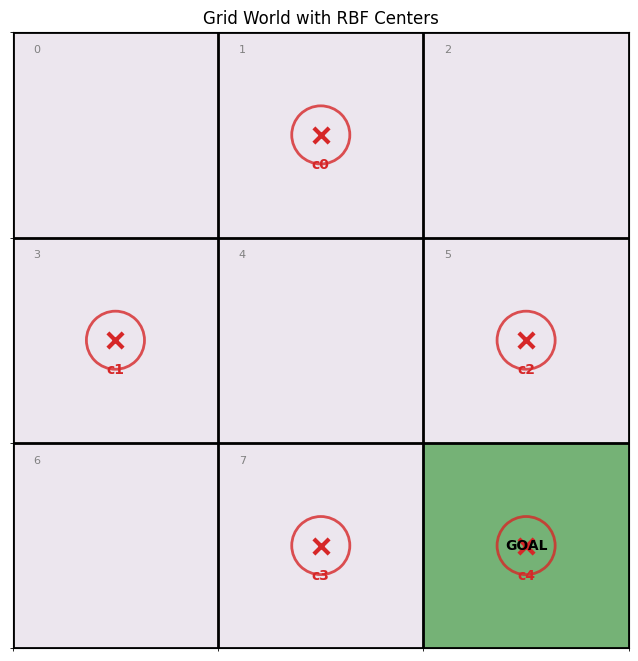

In [4]:
plot_grid_with_rbf(
    grid_size=3,
    centers=policy_centers,
    variance=value_features.variance,
    goal_grid=goal_grid,
    terminal_states={goal_grid},
)

In [4]:
solver_sbeed = SBEEDSolverSGDRho(
    spec=mdp_spec,
    lambda_entropy=0.01,
    eta=0.01,
    ridge=1e-6,
    lr_value=1e-3,
    lr_policy=1e-3,
    lr_rho=1e-3,
    tau=10000.0,
    buffer_mode="fifo",
    max_buffer_size=10000,
    batch_size=256,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=1500,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=1000,
    start_state=x_0,
    behavior="policy",
    epsilon=0.3,
    terminal_states={goal_grid},
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/1500 buffer=2000 objective=0.044092 primal_mse=0.044515 dual_mse=0.042284 theta_grad=3.399e-02 policy_grad=4.697e-02
episode=100/1500 buffer=3000 objective=0.039942 primal_mse=0.040312 dual_mse=0.037028 theta_grad=1.587e-02 policy_grad=3.763e-02
episode=150/1500 buffer=4000 objective=0.037351 primal_mse=0.037692 dual_mse=0.034095 theta_grad=1.755e-02 policy_grad=2.815e-02
episode=200/1500 buffer=5000 objective=0.036461 primal_mse=0.036795 dual_mse=0.033440 theta_grad=2.849e-02 policy_grad=4.705e-02
episode=250/1500 buffer=6000 objective=0.035661 primal_mse=0.035992 dual_mse=0.033074 theta_grad=5.341e-02 policy_grad=6.351e-02
episode=300/1500 buffer=7000 objective=0.035053 primal_mse=0.035383 dual_mse=0.033019 theta_grad=2.940e-02 policy_grad=4.609e-02
episode=350/1500 buffer=8000 objective=0.034406 primal_mse=0.034735 dual_mse=0.032879 theta_grad=3.013e-02 policy_grad=5.041e-02
episode=400/1500 buffer=9000 objective=0.034654 primal_mse=0.034993 dual_mse=0.033954 theta_grad=3

In [5]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
    terminal_states={goal_grid}, 
)

evaluator.print_policy()

stats = evaluator.reward_comparison(
    n_trajectories=10,
    max_steps=100,
    seed=42,
)

print(f"SBEED avg reward:    {stats['learned']['avg_reward']:.4f}")
print(f"SBEED reward std:    {stats['learned']['std_reward']:.4f}")
print(f"Uniform avg reward:  {stats['uniform']['avg_reward']:.4f}")
print(f"Uniform reward std:  {stats['uniform']['std_reward']:.4f}")
print(f"Optimal avg reward:  {stats['optimal']['avg_reward']:.4f}")
print(f"Optimal reward std:  {stats['optimal']['std_reward']:.4f}")


========== SBEED POLICY ==========

State 0: pi(0|0)=0.204  pi(1|0)=0.297  pi(2|0)=0.204  pi(3|0)=0.295  --> best action: 1
State 1: pi(0|1)=0.204  pi(1|1)=0.302  pi(2|1)=0.200  pi(3|1)=0.295  --> best action: 1
State 2: pi(0|2)=0.202  pi(1|2)=0.305  pi(2|2)=0.202  pi(3|2)=0.291  --> best action: 1
State 3: pi(0|3)=0.199  pi(1|3)=0.298  pi(2|3)=0.203  pi(3|3)=0.299  --> best action: 3
State 4: pi(0|4)=0.199  pi(1|4)=0.301  pi(2|4)=0.199  pi(3|4)=0.300  --> best action: 1
State 5: pi(0|5)=0.186  pi(1|5)=0.359  pi(2|5)=0.185  pi(3|5)=0.269  --> best action: 1
State 6: pi(0|6)=0.202  pi(1|6)=0.293  pi(2|6)=0.202  pi(3|6)=0.303  --> best action: 3
State 7: pi(0|7)=0.185  pi(1|7)=0.270  pi(2|7)=0.185  pi(3|7)=0.360  --> best action: 3
State 8: pi(0|8)=0.196  pi(1|8)=0.305  pi(2|8)=0.195  pi(3|8)=0.304  --> best action: 1


SBEED avg reward:    -0.8400
SBEED reward std:    1.1834
Uniform avg reward:  -1.6600
Uniform reward std:  2.0071
Optimal avg reward:  0.7000
Optimal reward std:  0.0000

# 5 Grid

## Deterministic

In [6]:
states = torch.arange(25, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

grid_size = 5

x_0 = 0

goal_grid = 24
pit_grid = 18

wall_states = {6, 7, 12}
terminal_states = {goal_grid, pit_grid}

def state_to_pos(s):
    s = int(s)
    return divmod(s, grid_size)


def pos_to_state(row, col):
    return row * grid_size + col


def move_deterministic(s, a):
    """
    Deterministic transition used internally.

    This function returns the next state after applying action a.
    It does not return probabilities.
    """
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = state_to_pos(s)

    if a == 0:      # up
        new_row, new_col = row - 1, col
    elif a == 1:    # down
        new_row, new_col = row + 1, col
    elif a == 2:    # left
        new_row, new_col = row, col - 1
    elif a == 3:    # right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0,1,2,3}")

    if not (0 <= new_row < grid_size and 0 <= new_col < grid_size):
        return s

    sp = pos_to_state(new_row, new_col)

    if sp in wall_states:
        return s

    return sp


def transition_probs(s, a):
    """
    Return transition distribution for state-action pair.

    Returns:
        List of (next_state, probability)
    """
    sp = move_deterministic(s, a)
    return [(sp, 1.0)]


def next_state(s, a):
    """
    Sample or select next state.

    For deterministic transitions this just returns the only possible next state.
    This keeps compatibility with your previous code.
    """
    probs = transition_probs(s, a)
    return probs[0][0]


def reward_fn(s, a, sp):
    sp = int(sp)

    if sp == goal_grid:
        return 1.0

    if sp == pit_grid:
        return -1.0

    return -0.1

center_lin = torch.linspace(0.0, 1.0, 4, dtype=torch.float64)

centers = torch.tensor(
    [[r, c] for r in center_lin for c in center_lin],
    dtype=torch.float64,
)


state_coords = torch.tensor(
    [[r / 4.0, c / 4.0] for r in range(5) for c in range(5)],
    dtype=torch.float64,
)

# centers = state_coords.clone()

value_features = RBFStateFeatures(
    n_states=N,
    centers=centers,
    state_coords=state_coords,
    bandwidth="nearest",
    bandwidth_scale = 0.25,
    include_bias=True,
)

rho_features = RBFStateActionFeatures(
    state_features=value_features,
    n_actions=A,
)

# policy_centers = state_coords.clone()

policy_centers = centers

policy_features = RBFStateFeatures(
    n_states=N,
    centers=policy_centers,
    state_coords=state_coords,
    bandwidth="nearest",
    bandwidth_scale = 0.55,
    include_bias=True,
)
mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    policy_features=policy_features,
    x0=x_0,
)

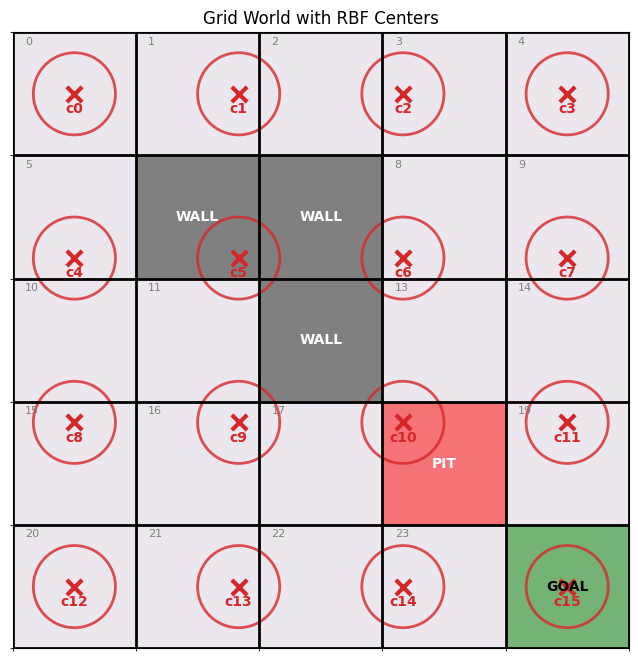

In [7]:
plot_grid_with_rbf(
    grid_size=5,
    centers=policy_centers,
    variance=value_features.variance,
    goal_grid=goal_grid,
    pit_grid=pit_grid,        
    wall_states=wall_states, 
    terminal_states={goal_grid, pit_grid},
)

In [8]:
solver_sbeed = SBEEDSolverSGDRho(
    spec=mdp_spec,
    lambda_entropy=0.075,
    eta=0.02,
    ridge=1e-3,
    lr_value=5e-2,
    lr_policy= 0.75,
    lr_rho=1e-2,
    tau=50000.0,
    buffer_mode="fifo",
    max_buffer_size=10000,
    batch_size=512,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=1000,
    collect_per_episode=30,
    updates_per_episode=20,
    initial_collect_steps=1000,
    start_state=x_0,
    behavior="policy",
    epsilon=0.3,
    terminal_states=terminal_states,
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/1000 buffer=2500 objective=0.008285 primal_mse=0.008457 dual_mse=0.008641 theta_grad=4.409e-03 policy_grad=1.090e-02
episode=100/1000 buffer=4000 objective=0.006169 primal_mse=0.006332 dual_mse=0.008139 theta_grad=2.096e-03 policy_grad=7.968e-03
episode=150/1000 buffer=5500 objective=0.005508 primal_mse=0.005654 dual_mse=0.007330 theta_grad=1.367e-02 policy_grad=6.001e-03
episode=200/1000 buffer=7000 objective=0.004882 primal_mse=0.005004 dual_mse=0.006104 theta_grad=8.684e-03 policy_grad=6.478e-03
episode=250/1000 buffer=8500 objective=0.004682 primal_mse=0.004805 dual_mse=0.006110 theta_grad=7.754e-03 policy_grad=4.184e-03
episode=300/1000 buffer=10000 objective=0.004381 primal_mse=0.004504 dual_mse=0.006157 theta_grad=2.702e-03 policy_grad=5.270e-03
episode=350/1000 buffer=10000 objective=0.003747 primal_mse=0.003875 dual_mse=0.006412 theta_grad=4.374e-03 policy_grad=4.364e-03
episode=400/1000 buffer=10000 objective=0.003620 primal_mse=0.003759 dual_mse=0.006948 theta_gra

In [9]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
    terminal_states={goal_grid}, 
)

evaluator.print_policy()

stats = evaluator.reward_comparison(
    n_trajectories=10,
    max_steps=100,
    seed=42,
)

print(f"SBEED avg reward:    {stats['learned']['avg_reward']:.4f}")
print(f"SBEED reward std:    {stats['learned']['std_reward']:.4f}")
print(f"Uniform avg reward:  {stats['uniform']['avg_reward']:.4f}")
print(f"Uniform reward std:  {stats['uniform']['std_reward']:.4f}")
print(f"Optimal avg reward:  {stats['optimal']['avg_reward']:.4f}")
print(f"Optimal reward std:  {stats['optimal']['std_reward']:.4f}")


========== SBEED POLICY ==========

State 0: pi(0|0)=0.183  pi(1|0)=0.322  pi(2|0)=0.189  pi(3|0)=0.306  --> best action: 1
State 1: pi(0|1)=0.204  pi(1|1)=0.208  pi(2|1)=0.108  pi(3|1)=0.480  --> best action: 3
State 2: pi(0|2)=0.212  pi(1|2)=0.271  pi(2|2)=0.096  pi(3|2)=0.421  --> best action: 3
State 3: pi(0|3)=0.209  pi(1|3)=0.425  pi(2|3)=0.126  pi(3|3)=0.240  --> best action: 1
State 4: pi(0|4)=0.167  pi(1|4)=0.486  pi(2|4)=0.141  pi(3|4)=0.207  --> best action: 1
State 5: pi(0|5)=0.113  pi(1|5)=0.471  pi(2|5)=0.195  pi(3|5)=0.220  --> best action: 1
State 6: pi(0|6)=0.075  pi(1|6)=0.088  pi(2|6)=0.044  pi(3|6)=0.793  --> best action: 3
State 7: pi(0|7)=0.078  pi(1|7)=0.018  pi(2|7)=0.057  pi(3|7)=0.847  --> best action: 3
State 8: pi(0|8)=0.135  pi(1|8)=0.035  pi(2|8)=0.257  pi(3|8)=0.573  --> best action: 3
State 9: pi(0|9)=0.089  pi(1|9)=0.347  pi(2|9)=0.222  pi(3|9)=0.343  --> best action: 1
State 10: pi(0|10)=0.089  pi(1|10)=0.417  pi(2|10)=0.205  pi(3|10)=0.289  --> best 

Much more difficult to do converge! 4x4 is really the limit, mostrly in state 0,1,2.... shared weights but different actions. Exploration is really important (epsilon) to do it working.

## Stochastic

In [10]:
policy_centers = state_coords.clone()

policy_features = RBFStateFeatures(
    n_states=N,
    centers=policy_centers,
    state_coords=state_coords,
    bandwidth="nearest",
    bandwidth_scale=0.10,
    include_bias=False,
)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    policy_features=policy_features,
    x0=x_0,
)

In [11]:
def transition_probs(s, a):
    """
    Stochastic transition:
    80% intended action
    20% random action uniformly over all actions.
    """
    s = int(s)
    a = int(a)

    probs_by_state = {}

    for candidate_a in range(A):
        if candidate_a == a:
            prob = 0.8 + 0.2 / A
        else:
            prob = 0.2 / A

        sp = move_deterministic(s, candidate_a)
        probs_by_state[sp] = probs_by_state.get(sp, 0.0) + prob

    return list(probs_by_state.items())

def next_state(s, a):
    probs = transition_probs(s, a)

    next_states = [sp for sp, p in probs]
    probabilities = torch.tensor([p for sp, p in probs], dtype=torch.float)

    idx = torch.multinomial(probabilities, num_samples=1).item()

    return next_states[idx]

Easy now the convergence! At the end is much better doing this solver than the one with updates for rho in batchs and linear regression.

In [12]:
solver_sbeed = SBEEDSolverSGDRho(
    spec=mdp_spec,
    lambda_entropy=0.075,
    eta=0.02,
    ridge=1e-3,
    lr_value=5e-2,
    lr_policy= 0.75,
    lr_rho=1e-2,
    tau=50000.0,
    buffer_mode="fifo",
    max_buffer_size=10000,
    batch_size=512,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=1000,
    collect_per_episode=30,
    updates_per_episode=20,
    initial_collect_steps=1000,
    start_state=x_0,
    behavior="policy",
    epsilon=0.3,
    terminal_states=terminal_states,
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/1000 buffer=2500 objective=0.007350 primal_mse=0.007527 dual_mse=0.008828 theta_grad=2.898e-03 policy_grad=5.536e-03
episode=100/1000 buffer=4000 objective=0.006084 primal_mse=0.006274 dual_mse=0.009495 theta_grad=1.400e-02 policy_grad=3.426e-03
episode=150/1000 buffer=5500 objective=0.005988 primal_mse=0.006136 dual_mse=0.007404 theta_grad=5.071e-03 policy_grad=7.016e-03
episode=200/1000 buffer=7000 objective=0.005263 primal_mse=0.005395 dual_mse=0.006573 theta_grad=1.079e-02 policy_grad=6.085e-03
episode=250/1000 buffer=8500 objective=0.005221 primal_mse=0.005357 dual_mse=0.006825 theta_grad=7.286e-03 policy_grad=7.541e-03
episode=300/1000 buffer=10000 objective=0.005366 primal_mse=0.005504 dual_mse=0.006901 theta_grad=6.983e-03 policy_grad=4.099e-03
episode=350/1000 buffer=10000 objective=0.004960 primal_mse=0.005095 dual_mse=0.006755 theta_grad=3.277e-03 policy_grad=4.418e-03
episode=400/1000 buffer=10000 objective=0.005351 primal_mse=0.005510 dual_mse=0.007954 theta_gra

In [13]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
    terminal_states={goal_grid}, 
)

evaluator.print_policy()

stats = evaluator.reward_comparison(
    n_trajectories=10,
    max_steps=100,
    seed=42,
)

print(f"SBEED avg reward:    {stats['learned']['avg_reward']:.4f}")
print(f"SBEED reward std:    {stats['learned']['std_reward']:.4f}")
print(f"Uniform avg reward:  {stats['uniform']['avg_reward']:.4f}")
print(f"Uniform reward std:  {stats['uniform']['std_reward']:.4f}")
print(f"Optimal avg reward:  {stats['optimal']['avg_reward']:.4f}")
print(f"Optimal reward std:  {stats['optimal']['std_reward']:.4f}")


========== SBEED POLICY ==========

State 0: pi(0|0)=0.235  pi(1|0)=0.262  pi(2|0)=0.236  pi(3|0)=0.267  --> best action: 3
State 1: pi(0|1)=0.236  pi(1|1)=0.242  pi(2|1)=0.213  pi(3|1)=0.308  --> best action: 3
State 2: pi(0|2)=0.264  pi(1|2)=0.273  pi(2|2)=0.201  pi(3|2)=0.262  --> best action: 1
State 3: pi(0|3)=0.234  pi(1|3)=0.237  pi(2|3)=0.247  pi(3|3)=0.281  --> best action: 3
State 4: pi(0|4)=0.232  pi(1|4)=0.319  pi(2|4)=0.208  pi(3|4)=0.241  --> best action: 1
State 5: pi(0|5)=0.211  pi(1|5)=0.316  pi(2|5)=0.236  pi(3|5)=0.237  --> best action: 1
State 6: pi(0|6)=0.250  pi(1|6)=0.250  pi(2|6)=0.250  pi(3|6)=0.250  --> best action: 0
State 7: pi(0|7)=0.250  pi(1|7)=0.250  pi(2|7)=0.250  pi(3|7)=0.250  --> best action: 0
State 8: pi(0|8)=0.220  pi(1|8)=0.222  pi(2|8)=0.223  pi(3|8)=0.335  --> best action: 3
State 9: pi(0|9)=0.161  pi(1|9)=0.458  pi(2|9)=0.142  pi(3|9)=0.239  --> best action: 1
State 10: pi(0|10)=0.188  pi(1|10)=0.272  pi(2|10)=0.259  pi(3|10)=0.281  --> best 